### This notebook produces two panels that are used in a draft figure for an ACE2 proposal and a manuscript for publication.

#### The first panel plots the number of TCs generated per year as a function of the MJO phase.  Later in the notebook these numbers are rescaled to better match observations.  

#### The second panel plots the percentage of time in June-November (left) or August-September (right) during which the MJO is in phases 1,2, or 3.  

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
import sys
#sys.path.append('/barnes-engr-scratch1/c832572266/Function/')
sys.path.append('/home/C823281551/code/pythonCode/TC_genesis_ACE2_evaluation_public/function/')
from scipy import signal
#import KW_diagnostics as KW
import mjo_mean_state_diagnostics_uw as MJO
import os
import cartopy.util as cartopy_util
import cartopy.crs as ccrs
from datetime import datetime, timezone

In [3]:
dirstr    = '/bell-scratch/C823281551/'
#dirstr2   = '/bell-scratch/C823281551/'
DIR       = dirstr + 'code/pythonCode/ACE2/'
file_dir  = DIR
file_dir2 = dirstr + 'data/ACE2/'

# Load basin info
basin_list    = list(['NI','NWPAC','NEPAC','NATL','SI','SPAC'])
basin_long_list = list(['North IO','North WestPac','North EastPac','North Atl','South IO','South Pac'])
basin_lon_min = np.array([45, 105, 180, 265, 35, 135])
basin_lon_max = np.array([105, 180, 265, 357.5, 135, 270])
latmax = 30 #25 is not used, use 30
basin_lat_min = np.array([0,    0,    0,  0,  -latmax, -latmax])
basin_lat_max = np.array([latmax,  latmax, latmax, latmax,    0, 0])
nbasin        = np.size(basin_list)

In [4]:
all_stars = np.zeros((40,8))
all_stars_05 = np.zeros((40,8))
all_stars_13 = np.zeros((40,8))

# go big or go home 
yr = '2024'
totind=0
ensarr    = ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10']
decarr    = ['dec01', 'dec02', 'dec03', 'dec04']
for ind in range(0, 10):
    ensnum  = ensarr[ind]
    for ind2 in range(0, 4):
        dstr    = decarr[ind2]
        filstr  = '_'+yr+'_'+dstr+'_'+ensnum+'_'
        file    = 'TC_genesis_number_8phase_basin_ACE2'+filstr+'summer.npz'
        fa      = np.load(file_dir2+file)
        TC_fa   = fa['TC_genesis_MJO_phase_basin']
        all_stars[totind,:] = TC_fa[:,3]
        filstr  = '_2005_'+dstr+'_'+ensnum+'_'
        file    = 'TC_genesis_number_8phase_basin_ACE2'+filstr+'summer.npz'
        fa      = np.load(file_dir2+file)
        TC_fa   = fa['TC_genesis_MJO_phase_basin']
        all_stars_05[totind,:] = TC_fa[:,3]
        filstr  = '_2013_'+dstr+'_'+ensnum+'_'
        file    = 'TC_genesis_number_8phase_basin_ACE2'+filstr+'summer.npz'
        fa      = np.load(file_dir2+file)
        TC_fa   = fa['TC_genesis_MJO_phase_basin']
        all_stars_13[totind,:] = TC_fa[:,3]
        #print(fa.files)
        print('file string',filstr)
        #print('ense index is',ensarr[ind])
        #print('dec index is',decarr[ind2])
        totind = totind + 1

mn_all_stars = np.mean(all_stars,axis=0) # compute the mean value along each MJO phase
mn_all_stars
mn_all_stars_05 = np.mean(all_stars_05,axis=0) # compute the mean value along each MJO phase
mn_all_stars_05
mn_all_stars_13 = np.mean(all_stars_13,axis=0) # compute the mean value along each MJO phase
mn_all_stars_13

file string _2013_dec01_01_
file string _2013_dec02_01_
file string _2013_dec03_01_
file string _2013_dec04_01_
file string _2013_dec01_02_
file string _2013_dec02_02_
file string _2013_dec03_02_
file string _2013_dec04_02_
file string _2013_dec01_03_
file string _2013_dec02_03_
file string _2013_dec03_03_
file string _2013_dec04_03_
file string _2013_dec01_04_
file string _2013_dec02_04_
file string _2013_dec03_04_
file string _2013_dec04_04_
file string _2013_dec01_05_
file string _2013_dec02_05_
file string _2013_dec03_05_
file string _2013_dec04_05_
file string _2013_dec01_06_
file string _2013_dec02_06_
file string _2013_dec03_06_
file string _2013_dec04_06_
file string _2013_dec01_07_
file string _2013_dec02_07_
file string _2013_dec03_07_
file string _2013_dec04_07_
file string _2013_dec01_08_
file string _2013_dec02_08_
file string _2013_dec03_08_
file string _2013_dec04_08_
file string _2013_dec01_09_
file string _2013_dec02_09_
file string _2013_dec03_09_
file string _2013_de

array([0.6  , 0.925, 0.975, 0.375, 0.575, 0.65 , 0.25 , 0.55 ])

In [23]:
all_starsb = np.zeros((40,9))
all_stars_05b = np.zeros((40,9))
all_stars_13b = np.zeros((40,9))

# go big or go home 
yr = '2024'
totind=0
ensarr    = ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10']
decarr    = ['dec01', 'dec02', 'dec03', 'dec04']
for ind in range(0, 10):
    ensnum  = ensarr[ind]
    for ind2 in range(0, 4):
        dstr    = decarr[ind2]
        filstr  = '_'+yr+'_'+dstr+'_'+ensnum+'_'
        file    = 'TC_genesis_number_9phase_basin_ACE2'+filstr+'summer.npz'
        fa      = np.load(file_dir2+file)
        TC_fa   = fa['TC_genesis_MJO_phase_basin']
        all_starsb[totind,:] = TC_fa[:,3]
        filstr  = '_2005_'+dstr+'_'+ensnum+'_'
        file    = 'TC_genesis_number_9phase_basin_ACE2'+filstr+'summer.npz'
        fa      = np.load(file_dir2+file)
        TC_fa   = fa['TC_genesis_MJO_phase_basin']
        all_stars_05b[totind,:] = TC_fa[:,3]
        filstr  = '_2013_'+dstr+'_'+ensnum+'_'
        file    = 'TC_genesis_number_9phase_basin_ACE2'+filstr+'summer.npz'
        fa      = np.load(file_dir2+file)
        TC_fa   = fa['TC_genesis_MJO_phase_basin']
        all_stars_13b[totind,:] = TC_fa[:,3]
        #print(fa.files)
        print('file string',filstr)
        #print('ense index is',ensarr[ind])
        #print('dec index is',decarr[ind2])
        totind = totind + 1

mn_all_starsb = np.mean(all_starsb,axis=0) # compute the mean value along each MJO phase
mn_all_starsb
mn_all_stars_05b = np.mean(all_stars_05b,axis=0) # compute the mean value along each MJO phase
mn_all_stars_05b
mn_all_stars_13b = np.mean(all_stars_13b,axis=0) # compute the mean value along each MJO phase
mn_all_stars_13b

# calculate confidence intervals
nphase = 9
ibasin = 3
#for ibasin in range(0, nbasin):
zeros = np.zeros([nphase])
phase = np.arange(1,10)
    #plt.plot(phase, TC_genesis_MJO_phase_basin_ano[:,ibasin]/10)
#fig, ax = plt.subplots(figsize=(8, 6))

# Calculate 95% confidence interval for the 40 ensemble members
std_all_starsb = np.std(all_starsb, axis=0)
se_all_starsb = std_all_stars / np.sqrt(all_starsb.shape[0])
ci_95_allb = 1.96 * se_all_stars

# Calculate 95% confidence interval for the 40 ensemble members from 2005
std_all_stars_05b = np.std(all_stars_05b, axis=0)
se_all_stars_05b = std_all_stars_05 / np.sqrt(all_stars_05b.shape[0])
ci_95_all_05b = 1.96 * se_all_stars_05

# Calculate 95% confidence interval for the 40 ensemble members from 2013
std_all_stars_13b = np.std(all_stars_13b, axis=0)
se_all_stars_13b = std_all_stars_13 / np.sqrt(all_stars_13b.shape[0])
ci_95_all_13b = 1.96 * se_all_stars_13

file string _2013_dec01_01_
file string _2013_dec02_01_
file string _2013_dec03_01_
file string _2013_dec04_01_
file string _2013_dec01_02_
file string _2013_dec02_02_
file string _2013_dec03_02_
file string _2013_dec04_02_
file string _2013_dec01_03_
file string _2013_dec02_03_
file string _2013_dec03_03_
file string _2013_dec04_03_
file string _2013_dec01_04_
file string _2013_dec02_04_
file string _2013_dec03_04_
file string _2013_dec04_04_
file string _2013_dec01_05_
file string _2013_dec02_05_
file string _2013_dec03_05_
file string _2013_dec04_05_
file string _2013_dec01_06_
file string _2013_dec02_06_
file string _2013_dec03_06_
file string _2013_dec04_06_
file string _2013_dec01_07_
file string _2013_dec02_07_
file string _2013_dec03_07_
file string _2013_dec04_07_
file string _2013_dec01_08_
file string _2013_dec02_08_
file string _2013_dec03_08_
file string _2013_dec04_08_
file string _2013_dec01_09_
file string _2013_dec02_09_
file string _2013_dec03_09_
file string _2013_de

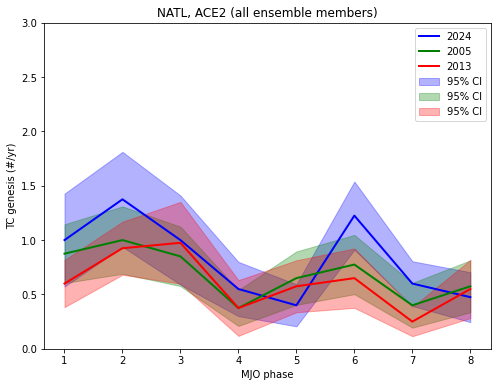

In [24]:
#yr2plot = '2024_allens'
nphase = 8
ibasin = 3
#for ibasin in range(0, nbasin):
zeros = np.zeros([nphase])
phase = np.arange(1,9)
    #plt.plot(phase, TC_genesis_MJO_phase_basin_ano[:,ibasin]/10)
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate 95% confidence interval for the 40 ensemble members
std_all_stars = np.std(all_stars, axis=0)
se_all_stars = std_all_stars / np.sqrt(all_stars.shape[0])
ci_95_all = 1.96 * se_all_stars

# Calculate 95% confidence interval for the 40 ensemble members from 2005
std_all_stars_05 = np.std(all_stars_05, axis=0)
se_all_stars_05 = std_all_stars_05 / np.sqrt(all_stars_05.shape[0])
ci_95_all_05 = 1.96 * se_all_stars_05

# Calculate 95% confidence interval for the 40 ensemble members from 2013
std_all_stars_13 = np.std(all_stars_13, axis=0)
se_all_stars_13 = std_all_stars_13 / np.sqrt(all_stars_13.shape[0])
ci_95_all_13 = 1.96 * se_all_stars_13

ax.fill_between(phase, mn_all_stars - ci_95_all, mn_all_stars + ci_95_all,
                alpha=0.3, color='blue', label='95% CI')
ax.plot(phase, mn_all_stars[:], 'b-', linewidth=2, label='2024')
ax.fill_between(phase, mn_all_stars_05 - ci_95_all_05, mn_all_stars_05 + ci_95_all_05,
                alpha=0.3, color='green', label='95% CI')
ax.plot(phase, mn_all_stars_05[:], 'g-', linewidth=2, label='2005')
ax.fill_between(phase, mn_all_stars_13 - ci_95_all_13, mn_all_stars_13 + ci_95_all_13,
                alpha=0.3, color='red', label='95% CI')
ax.plot(phase, mn_all_stars_13[:], 'r-', linewidth=2, label='2013')

ax.set_title(basin_list[ibasin]+', ACE2 (all ensemble members)')
ax.set_xticks(phase)
ax.set_ylim(0., 3.)
ax.set_xlabel('MJO phase')
ax.set_ylabel('TC genesis (#/yr)')
ax.legend(loc='upper right')
plt.show()

fig.savefig('all40_allyears.png', dpi=300)

In [25]:
# where did these numbers come from?  I am struggling to reproduce them.  
# numbers like these can be computed with the script: 
x = np.arange(3)
y1 = [22.8, 22.2, 25.5]
y2 = [20.9, 21.6, 22.8]
y3 = [21.1, 15.0, 20.5]
y4 = [13.2, 19.1, 14.4]
width = 0.2
#
# numbers computed on august 15th with calc_rmm_1yr.py on maui
# computed for phases of 1,2, and 3 of the mjo.
# active and quiet are defined based on the busiest and quietest 5 ensemble members.
y1n = [22.8, 22.9, 21.9] # 2005, 2013, 2024; june-nov
y2n = [21.4, 19.9, 20.1] # june-nov; quiet
y3n = [14.9, 19.4, 26.1] # aug-sep; active
y4n = [16.9, 18.1, 20.6] # aug-sep; quiet

# computed for extreme years, defined using quartiles
# computed for phases of 1,2, and 3 of the mjo.
# active and quiet are defined based on the busiest and quietest 5 ensemble members.
y1q = [21.7, 22.7, 22.4] # 2005, 2013, 2024; june-nov; active
y2q = [21.4, 20.6, 18.6] # june-nov; quiet
y3q = [12.4, 19.3, 23.3] # aug-sep; active
y4q = [16.9, 17.2, 19.0] # aug-sep; quiet

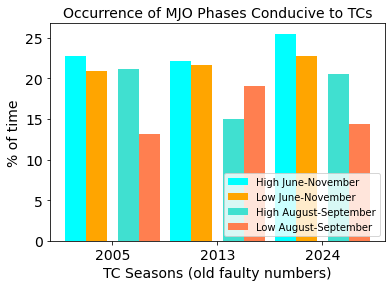

In [26]:
# plot data in grouped manner of bar type
fig, ax = plt.subplots()
plt.bar(x-0.35, y1, width, color='cyan')
plt.bar(x-0.15, y2, width, color='orange')
plt.bar(x+0.15, y3, width, color='turquoise')
plt.bar(x+0.35, y4, width, color='coral')
plt.title('Occurrence of MJO Phases Conducive to TCs', fontsize=14)
plt.yticks(fontsize=14)
plt.xticks(x, ['2005', '2013', '2024'], fontsize=14)
plt.xlabel("TC Seasons (old faulty numbers)", fontsize=14)
plt.ylabel("% of time", fontsize=14)
plt.legend(["High June-November", "Low June-November", "High August-September", "Low August-September"],loc="lower right")
fig.savefig('barchart_mjo_3yrs.png', dpi=300)
#plt.show()


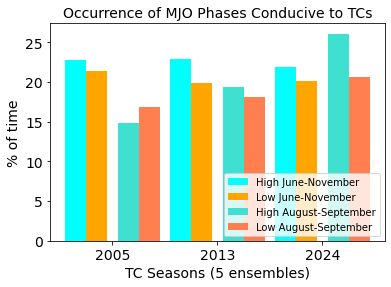

In [27]:
# plot data in grouped manner of bar type
fig, ax = plt.subplots()
plt.bar(x-0.35, y1n, width, color='cyan')
plt.bar(x-0.15, y2n, width, color='orange')
plt.bar(x+0.15, y3n, width, color='turquoise')
plt.bar(x+0.35, y4n, width, color='coral')
plt.title('Occurrence of MJO Phases Conducive to TCs', fontsize=14)
plt.yticks(fontsize=14)
plt.xticks(x, ['2005', '2013', '2024'], fontsize=14)
plt.xlabel("TC Seasons (5 ensembles)", fontsize=14)
plt.ylabel("% of time", fontsize=14)
plt.legend(["High June-November", "Low June-November", "High August-September", "Low August-September"],loc="lower right")
fig.savefig('barchart_mjo_3yrs.png', dpi=300)
#plt.show()

In [28]:
# extra cell

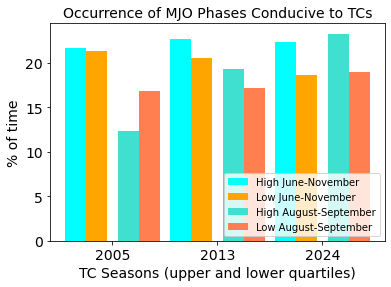

In [29]:
# mommy's little monster
# plot data in grouped manner of bar type
fig, ax = plt.subplots()
plt.bar(x-0.35, y1q, width, color='cyan')
plt.bar(x-0.15, y2q, width, color='orange')
plt.bar(x+0.15, y3q, width, color='turquoise')
plt.bar(x+0.35, y4q, width, color='coral')
plt.title('Occurrence of MJO Phases Conducive to TCs', fontsize=14)
plt.yticks(fontsize=14)
plt.xticks(x, ['2005', '2013', '2024'], fontsize=14)
plt.xlabel("TC Seasons (upper and lower quartiles)", fontsize=14)
plt.ylabel("% of time", fontsize=14)
plt.legend(["High June-November", "Low June-November", "High August-September", "Low August-September"],loc="lower right")
fig.savefig('barchart_mjo_3yrs.png', dpi=300)
#plt.show()

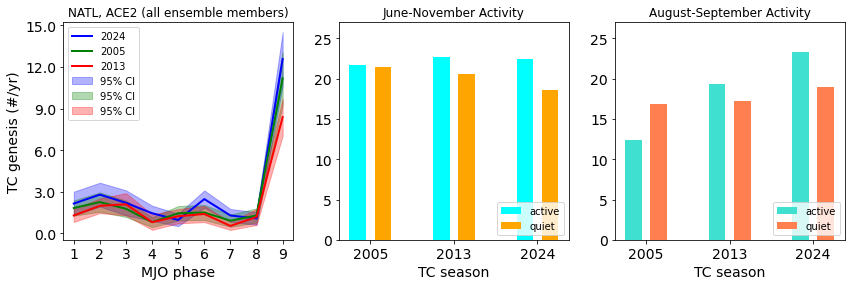

In [35]:
fig, ax = plt.subplots(1,3, figsize=(14, 4))
#fig, ax = plt.subplots(figsize=(6, 8))
#plt.subplots_adjust(hspace=0.4)

#nphase = 8
#ibasin = 3
#for ibasin in range(0, nbasin):
zeros = np.zeros([nphase])
phase = np.arange(1,10)
    #plt.plot(phase, TC_genesis_MJO_phase_basin_ano[:,ibasin]/10)

#plt.subplot(1,2,1)

#ax.fill_between(phase, mn_all_stars - ci_95_all, mn_all_stars + ci_95_all,
#                alpha=0.3, color='blue', label='95% CI')
#ax.plot(phase, mn_all_stars[:], 'b-', linewidth=2, label='2024')
#ax.fill_between(phase, mn_all_stars_05 - ci_95_all_05, mn_all_stars_05 + ci_95_all_05,
#                alpha=0.3, color='green', label='95% CI')
#ax.plot(phase, mn_all_stars_05[:], 'g-', linewidth=2, label='2005')
#
#ax[0].tick_params(axis='x', labelsize=14)
ax[0].fill_between(phase, mn_all_starsb - ci_95_allb, mn_all_starsb + ci_95_allb,
                alpha=0.3, color='blue', label='95% CI')
ax[0].plot(phase, mn_all_starsb[:], 'b-', linewidth=2, label='2024')
ax[0].fill_between(phase, mn_all_stars_05b - ci_95_all_05b, mn_all_stars_05b + ci_95_all_05b,
                alpha=0.3, color='green', label='95% CI')
ax[0].plot(phase, mn_all_stars_05b[:], 'g-', linewidth=2, label='2005')
ax[0].fill_between(phase, mn_all_stars_13b - ci_95_all_13b, mn_all_stars_13b + ci_95_all_13b,
                alpha=0.3, color='red', label='95% CI')
ax[0].plot(phase, mn_all_stars_13b[:], 'r-', linewidth=2, label='2013')

ax[0].tick_params(axis='both', which='major', labelsize=14)
#
ax[0].set_title(basin_list[ibasin]+', ACE2 (all ensemble members)')
ax[0].set_xticks(phase)
##ax[0].set_yticks(np.arange(0, 3.5, 0.5), fontsize=14)
#
#ax[0].set_title('N. Atlantic, ACE2 (all ensembles)')
#
## desired y-axis values: 
#c = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0])
c = np.array([0.0, 3.0, 6.0, 9.0, 12.0, 15.0])
newY = c/2.15 # scaling factor to compute the actual y-axis values
#
#ax[0].set_ylim(0., 2.5)
##ax[0].set_yticks([0.0, 0.5, 1.0, 1.5, 2.0, 2.5])
#ax[0].set_yticks(newY)
#ax[0].set_yticklabels(['0.0', '1.0', '2.0', '3.0', '4.0', '5.0'])
ax[0].set_xlabel('MJO phase', fontsize=14)
ax[0].set_ylabel('TC genesis (#/yr)', fontsize=14)
ax[0].set_yticks(newY)
ax[0].set_yticklabels(['0.0', '3.0', '6.0', '9.0', '12.0', '15.0'])
#ax[0].set_ylim(0, 2.0)
ax[0].legend(loc='upper left')
#
#plt.subplot(2,1,2)
#
## values are the percentage of November-June and August-September in which the MJO is in phases 1,2, or 3.  
ax[1].set_title('June-November Activity')
ax[1].set_xlabel('TC season', fontsize=14)
ax[1].bar(x-0.15, y1q, width, color='cyan')
ax[1].set_ylim(0, 27.)
#plt.bar(x-0.35, y1, width, color='cyan')
ax[1].bar(x+0.15, y2q, width, color='orange')
ax[1].set_xticks(x)
ax[1].set_xticklabels(['2005','2013','2024'])
#ax[1].tick_params(axis='x', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[1].legend(["active","quiet"], loc="lower right")
#plt.bar(x+0.15, y3, width, color='turquoise')
ax[2].set_xlabel('TC season', fontsize=14)
ax[2].set_title('August-September Activity')
ax[2].bar(x-0.15, y3q, width, color='turquoise')
ax[2].set_ylim(0, 27.)
ax[2].bar(x+0.15, y4q, width, color='coral')
#plt.title('Occurrence of MJO Phases Conducive to TCs', fontsize=14)
#plt.yticks(fontsize=14)
#plt.xticks(x, ['2005', '2013', '2024'], fontsize=14)
#ax[2].set_xticks(x, labels=['2005', '2013', '2024'])
ax[2].set_xticks(x)
ax[2].set_xticklabels(['2005','2013','2024'])
#ax[2].tick_params(axis='x', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
#plt.xlabel("TC Seasons", fontsize=14)
#plt.ylabel("% of time", fontsize=14)
#plt.legend(["High June-November", "Low June-November", "High August-September", "Low August-September"],loc="lower right")
plt.legend(["active", "quiet"],loc="lower right")
fig.savefig('ace2_mjo_3pan_9ph.png', dpi=300)

plt.show()


In [19]:
a=np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5])

In [20]:
b = a*2.15

In [21]:
c = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0])

In [22]:
newY = c/2.15

In [23]:
newY

array([0.        , 0.46511628, 0.93023256, 1.39534884, 1.86046512,
       2.3255814 ])

In [ ]:
# plot data in grouped manner of bar type
fig, ax = plt.subplots(1,2, figsize=(12,4))
#
plt.subplot(1,2,1)
plt.bar(x-0.15, y1, width, color='cyan')
plt.bar(x+0.15, y2, width, color='orange')
#plt.bar(x+0.15, y3, width, color='turquoise')
#plt.bar(x+0.35, y4, width, color='coral')
plt.title('Occurrence of MJO Phases Conducive to TCs', fontsize=14)
plt.yticks(fontsize=14)
ax[0].set_ylim(0., 3.)
plt.xticks(x, ['2005', '2013', '2024'], fontsize=14)
plt.xlabel("TC Seasons", fontsize=14)
plt.ylabel("% of time", fontsize=14)
plt.legend(["High June-November", "Low June-November", "High August-September", "Low August-September"],loc="lower right")
#
plt.subplot(1,2,2)
plt.bar(x-0.15, y3, width, color='cyan')
plt.bar(x+0.15, y4, width, color='orange')
#plt.bar(x+0.15, y3, width, color='turquoise')
#plt.bar(x+0.35, y4, width, color='coral')
plt.title('Occurrence of MJO Phases Conducive to TCs', fontsize=14)
plt.yticks(fontsize=14)
plt.xticks(x, ['2005', '2013', '2024'], fontsize=14)
plt.xlabel("TC Seasons", fontsize=14)
plt.ylabel("% of time", fontsize=14)
plt.legend(["High June-November", "Low June-November", "High August-September", "Low August-September"],loc="lower right")
fig.savefig('barchart_mjo_3yrs.png', dpi=300)
#plt.show()

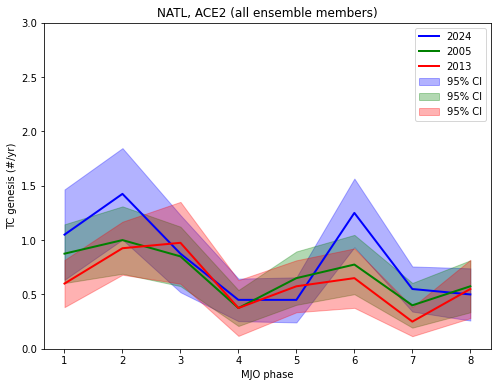

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.fill_between(phase, mn_all_stars - ci_95_all, mn_all_stars + ci_95_all,
                alpha=0.3, color='blue', label='95% CI')
ax.plot(phase, mn_all_stars[:], 'b-', linewidth=2, label='2024')
ax.fill_between(phase, mn_all_stars_05 - ci_95_all_05, mn_all_stars_05 + ci_95_all_05,
                alpha=0.3, color='green', label='95% CI')
ax.plot(phase, mn_all_stars_05[:], 'g-', linewidth=2, label='2005')
ax.fill_between(phase, mn_all_stars_13 - ci_95_all_13, mn_all_stars_13 + ci_95_all_13,
                alpha=0.3, color='red', label='95% CI')
ax.plot(phase, mn_all_stars_13[:], 'r-', linewidth=2, label='2013')

ax.set_title(basin_list[ibasin]+', ACE2 (all ensemble members)')
ax.set_xticks(phase)
ax.set_ylim(0., 3.)
ax.set_xlabel('MJO phase')
ax.set_ylabel('TC genesis (#/yr)')
ax.legend(loc='upper right')
plt.show()

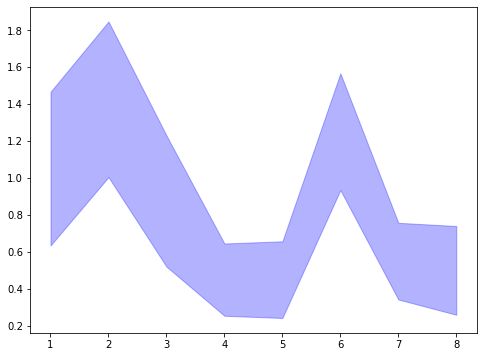

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.fill_between(phase, mn_all_stars - ci_95_all, mn_all_stars + ci_95_all,
                alpha=0.3, color='blue', label='95% CI')
plt.show()